# Selection des features

## Importation des bibliothèques

In [33]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

## Préparation des données traitées

In [34]:
df = pd.read_csv("../data/processed/processed_data.csv")

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9862 entries, 0 to 9861
Data columns (total 41 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   op_unique_carrier    9862 non-null   int64  
 1   op_carrier_fl_num    9862 non-null   float64
 2   origin               9862 non-null   int64  
 3   origin_city_name     9862 non-null   int64  
 4   origin_state_nm      9862 non-null   int64  
 5   dest                 9862 non-null   int64  
 6   dest_city_name       9862 non-null   int64  
 7   dest_state_nm        9862 non-null   int64  
 8   dep_delay            9862 non-null   float64
 9   taxi_out             9862 non-null   float64
 10  taxi_in              9862 non-null   float64
 11  arr_delay            9862 non-null   float64
 12  cancelled            9862 non-null   int64  
 13  diverted             9862 non-null   int64  
 14  crs_elapsed_time     9862 non-null   float64
 15  actual_elapsed_time  9862 non-null   f

In [36]:
# matrice des features
X = df.drop(columns=["arr_delay"], axis=1)
# variable cible -> celle que l'on veut prédire
# Transformation de la variable cible en binaire: 1 = delayed, 0 = not delayed
y = (df["arr_delay"]>0).astype(int)


## Séparation des données de test et d'entraînement

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

## Entraînement d'un modèle Random Forest (avant la selection des features)

In [38]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Evaluer le modèle
accuracy_before = rf.score(X_test, y_test)
print(f'Accuracy before feature selection: {accuracy_before:.2f}')

Accuracy before feature selection: 0.95


## Extraction des features importantes

                feature  importance
8             dep_delay    0.229523
19            nas_delay    0.169118
17        carrier_delay    0.167587
21  late_aircraft_delay    0.115195
9              taxi_out    0.036929
10              taxi_in    0.021707
18        weather_delay    0.015112
13     crs_elapsed_time    0.013900
14  actual_elapsed_time    0.013336
38             arr_hour    0.012263
34       wheels_on_hour    0.011992
1     op_carrier_fl_num    0.011278
15             air_time    0.011052
16             distance    0.010271
37          crs_arr_min    0.010002
32      wheels_off_hour    0.009360
35        wheels_on_min    0.008911
39              arr_min    0.008886
31              dep_min    0.008869
30             dep_hour    0.008483
33       wheels_off_min    0.008393
24               fl_day    0.008343
6        dest_city_name    0.008033
2                origin    0.007873
36         crs_arr_hour    0.007770
28         crs_dep_hour    0.007552
29          crs_dep_min    0

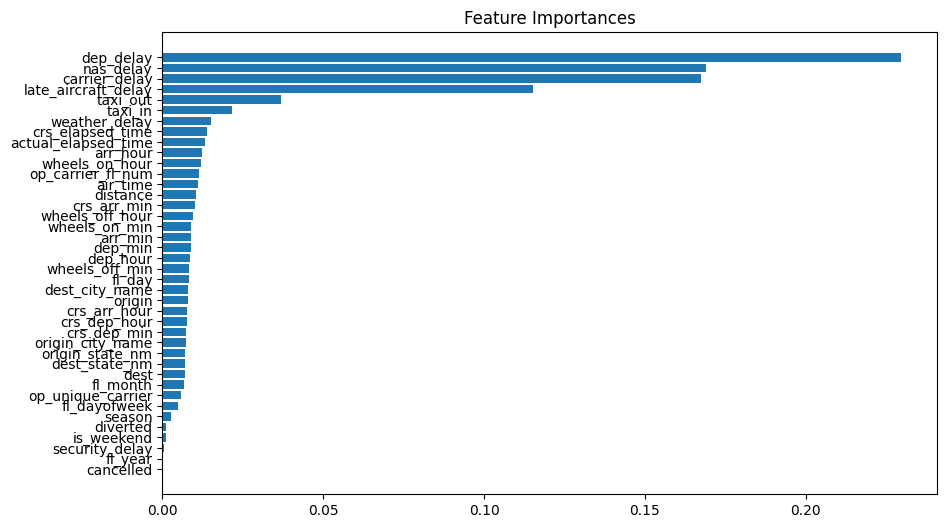

In [39]:
# Classement des features par ordre d'importance
feature_importances = pd.DataFrame({
    'feature' : X_train.columns,
    'importance' : rf.feature_importances_}).sort_values(by='importance', ascending=False)

print(feature_importances)

# Visualiser les top features
plt.figure(figsize=(10,6))
plt.barh(feature_importances['feature'], feature_importances['importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importances")
plt.show()

##

## Selection des top features

In [40]:
selected_features = feature_importances[feature_importances['importance']>0.01]['feature']
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]
